<a href="https://colab.research.google.com/github/Ravindra1972/Anaytics-in-finance-using-Python/blob/main/Stock_Market_Data_Obtaining_Data%2C_Visualization_%26_Analysis_in_Python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import yfinance package
import yfinance as yf

# Set the start and end date
start_date = '1990-01-01'
end_date = '2025-11-21'

# Set the ticker
ticker = 'AMZN'

# Get the data
data = yf.download(ticker, start_date, end_date, group_by=ticker, auto_adjust=False)[ticker]

# Print 5 rows
data.tail()

[*********************100%***********************]  1 of 1 completed


Price,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2025-11-14,235.059998,238.729996,232.889999,234.690002,234.690002,38956700
2025-11-17,233.250000,234.600006,229.190002,232.869995,232.869995,59919000
2025-11-18,228.100006,230.199997,222.419998,222.550003,222.550003,60608400
2025-11-19,223.740005,223.740005,218.520004,222.690002,222.690002,58335600
2025-11-20,227.050003,227.410004,216.740005,217.139999,217.139999,50309000


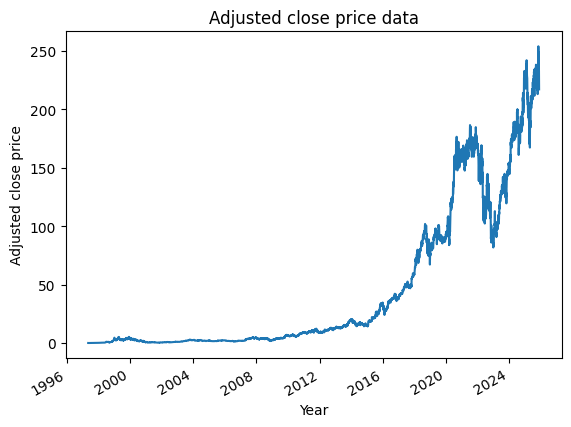

In [2]:
# Import matplotlib for plotting
import matplotlib.pyplot as plt
%matplotlib inline


# Plot adjusted close price data
data['Adj Close'].plot()
plt.xlabel('Year')
plt.ylabel('Adjusted close price')
plt.title('Adjusted close price data')
plt.show()

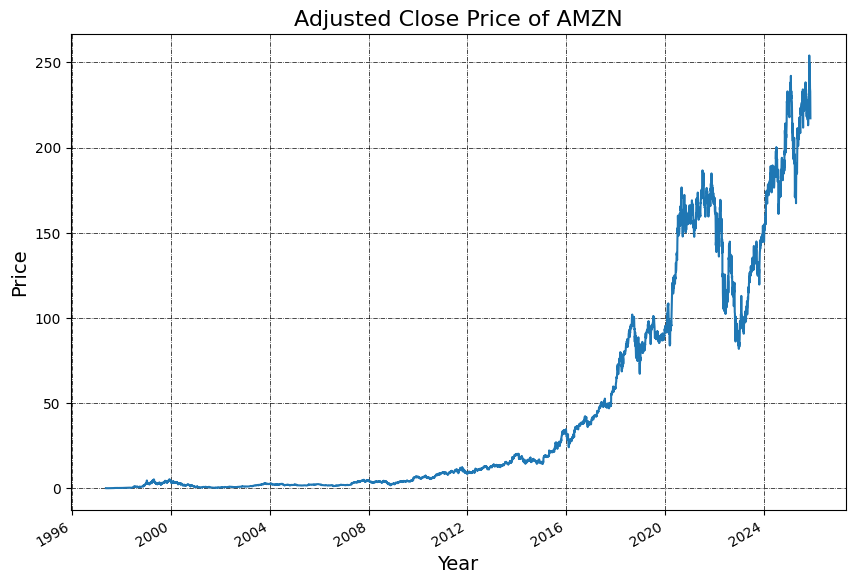

In [3]:
# Plot the adjusted close price
data['Adj Close'].plot(figsize=(10, 7))


# Define the label for the title of the figure
plt.title("Adjusted Close Price of %s" % ticker, fontsize=16)


# Define the labels for the x-axis and y-axis
plt.ylabel('Price', fontsize=14)
plt.xlabel('Year', fontsize=14)


# Plot the grid lines
plt.grid(which="major", color='k', linestyle='-.', linewidth=0.5)


# Show the plot
plt.show()

In [5]:
# Import packages
import yfinance as yf
import pandas as pd

# Set the start and end date
start_date = '1990-01-01'
end_date = '2025-11-21'

# Define the ticker list
tickers_list = ['AAPL', 'IBM', 'MSFT', 'WMT']

# Create placeholder for data
data = pd.DataFrame(columns=tickers_list)

# Fetch the data
for ticker in tickers_list:
    data[ticker] = yf.download(ticker,
                               start_date,
                               end_date, auto_adjust=False)['Adj Close']

# Print first 5 rows of the data
data.tail()


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


,AAPL,IBM,MSFT,WMT
Date,,,,
2025-11-14,272.410004,305.690002,509.226898,102.480003
2025-11-17,267.459991,297.170013,506.541931,102.949997
2025-11-18,267.440002,289.950012,492.867554,101.389999
2025-11-19,268.559998,288.529999,486.209991,100.610001
2025-11-20,266.250000,290.399994,478.429993,107.110001


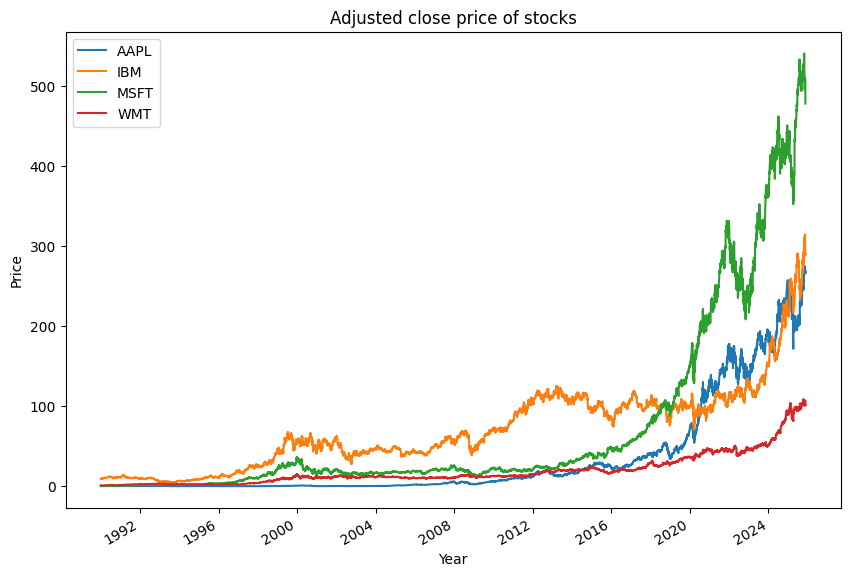

In [6]:
import matplotlib.pyplot as plt

data.plot(figsize=(10, 7))

# Add labels and title
plt.xlabel('Year')
plt.ylabel('Price')
plt.title('Adjusted close price of stocks')

# Show the plot
plt.show()


In [9]:
# Import packages
import yfinance as yf
import pandas as pd
import requests

# Read and print the stock tickers that make up S&P500
url = 'https://en.wikipedia.org/wiki/List_of_S%26P_500_companies'

# Add a User-Agent header to mimic a browser request
headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/91.0.4472.124 Safari/537.36'}
response = requests.get(url, headers=headers)

# Get all tables from the webpage
tables = pd.read_html(response.text)

# Find the table that contains the 'Symbol' column
tickers_df = None
for table in tables:
    if 'Symbol' in table.columns:
        tickers_df = table
        break

if tickers_df is not None:
    print(tickers_df.head())

    # Get the data for this tickers from yahoo finance
    data = yf.download(tickers_df.Symbol.to_list(),'2021-1-1','2024-08-1', auto_adjust=True)['Close']
    print(data.head())
else:
    print("Could not find a table with 'Symbol' column on the Wikipedia page.")

/tmp/ipython-input-705620591.py:14: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  tables = pd.read_html(response.text)


  Symbol             Security             GICS Sector  \
0    MMM                   3M             Industrials   
1    AOS          A. O. Smith             Industrials   
2    ABT  Abbott Laboratories             Health Care   
3   ABBV               AbbVie             Health Care   
4    ACN            Accenture  Information Technology   

                GICS Sub-Industry    Headquarters Location  Date added  \
0        Industrial Conglomerates    Saint Paul, Minnesota  1957-03-04   
1               Building Products     Milwaukee, Wisconsin  2017-07-26   
2           Health Care Equipment  North Chicago, Illinois  1957-03-04   
3                   Biotechnology  North Chicago, Illinois  2012-12-31   
4  IT Consulting & Other Services          Dublin, Ireland  2011-07-06   

       CIK      Founded  
0    66740         1902  
1    91142         1916  
2     1800         1888  
3  1551152  2013 (1888)  
4  1467373         1989  


[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
4 Failed downloads:
ERROR:yfinance:['Q', 'SOLS']: YFPricesMissingError('possibly delisted; no price data found  (1d 2021-1-1 -> 2024-08-1) (Yahoo error = "Data doesn\'t exist for startDate = 1609477200, endDate = 1722484800")')
ERROR:yfinance:['BF.B']: YFPricesMissingError('possibly delisted; no price data found  (1d 2021-1-1 -> 2024-08-1)')
ERROR:yfinance:['BRK.B']: YFTzMissingError('possibly delisted; no timezone found')


Ticker               A        AAPL       ABBV        ABNB         ABT  \
Date                                                                    
2021-01-04  114.864677  125.974457  86.739708  139.149994   99.687302   
2021-01-05  115.803787  127.531967  87.636650  148.300003  100.920723   
2021-01-06  118.979431  123.239067  86.879585  142.770004  100.710587   
2021-01-07  122.145386  127.444382  87.809456  151.270004  101.688179   
2021-01-08  123.016724  128.544357  88.270256  149.770004  101.971420   

Ticker           ACGL         ACN        ADBE         ADI        ADM  ...  \
Date                                                                  ...   
2021-01-04  33.186359  238.710403  485.339996  134.281326  43.384045  ...   
2021-01-05  33.319485  240.069351  485.690002  136.681519  44.227894  ...   
2021-01-06  34.783871  242.694168  466.309998  137.297638  46.019978  ...   
2021-01-07  34.460564  244.983948  477.739990  143.100403  45.611099  ...   
2021-01-08  34.650742  245

[*********************100%***********************]  1 of 1 completed


<Figure size 1200x600 with 0 Axes>

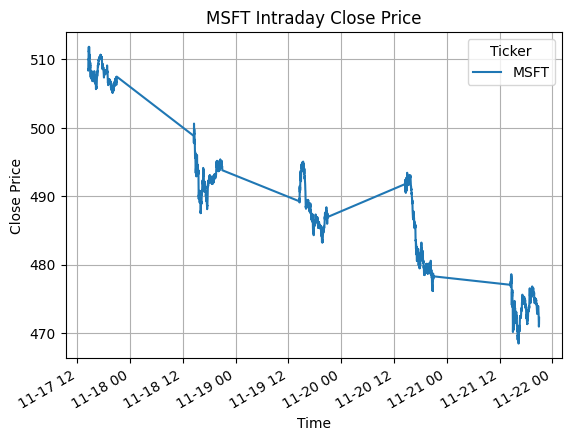

In [12]:
import matplotlib.pyplot as plt
import yfinance as yf

# Get intraday data for MSFT
intraday_data = yf.download(tickers="MSFT",
                            period="5d",
                            interval="1m",
                            auto_adjust=True)

# Plot the intraday close price of MSFT
plt.figure(figsize=(12, 6))
intraday_data['Close'].plot()
plt.title('MSFT Intraday Close Price')
plt.xlabel('Time')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()

In [13]:
import yfinance as yf
intraday_data = yf.download(tickers="MSFT",
                            period="5d",
                            interval="1m",
                            auto_adjust=True)
intraday_data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Datetime,,,,,
2025-11-17 14:30:00+00:00,508.510101,508.640015,506.179993,508.445007,849389
2025-11-17 14:31:00+00:00,508.359985,509.149994,507.549988,508.549988,80013
2025-11-17 14:32:00+00:00,509.940002,510.350006,508.230011,508.480011,120479
2025-11-17 14:33:00+00:00,510.029999,510.429993,509.670013,509.980011,60649
2025-11-17 14:34:00+00:00,509.970001,510.290009,509.720001,510.049988,30449


In [14]:
ohlcv_dict = {
 'Open': 'first',
 'High': 'max',
 'Low': 'min',
 'Close': 'last',
 'Volume': 'sum'
}

In [15]:
# Import package & get the data
import yfinance as yf
intraday_data = yf.download(tickers="MSFT",
                            period="5d",
                            interval="1m",
                            auto_adjust=True, group_by='ticker')["MSFT"]

# Define the resampling logic
ohlcv_dict = {
     'Open': 'first',
     'High': 'max',
     'Low': 'min',
     'Close': 'last',
     'Volume': 'sum'
}

# Resample the data
intraday_data_10 = intraday_data.resample('10T').agg(ohlcv_dict)
intraday_data_10.head()

[*********************100%***********************]  1 of 1 completed
/tmp/ipython-input-1419682564.py:18: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  intraday_data_10 = intraday_data.resample('10T').agg(ohlcv_dict)


Price,Open,High,Low,Close,Volume
Datetime,,,,,
2025-11-17 14:30:00+00:00,508.445007,512.119995,506.179993,511.095001,1933352
2025-11-17 14:40:00+00:00,511.044800,511.920013,510.100006,510.605194,293343
2025-11-17 14:50:00+00:00,510.720001,511.170013,508.500000,508.959991,349823
2025-11-17 15:00:00+00:00,508.920013,509.390015,506.904999,507.209991,316977
2025-11-17 15:10:00+00:00,507.209991,508.559998,507.089996,507.845001,246382


In [16]:
# Import yfinance
import yfinance as yf

# Set the ticker as MSFT
msft = yf.Ticker("MSFT")

In [17]:
# fetch the latest price to book ratio and price to earnings ratio

# Get the latest price to book ratio
pb_ratio = msft.info['priceToBook']
print('Price to Book Ratio is: ', pb_ratio)
# Get the latest price to earnings ratio
pe_ratio = msft.info['trailingPE']
print('Price to Earnings Ratio is: ', pe_ratio)


Price to Book Ratio is:  9.666667
Price to Earnings Ratio is:  33.55508


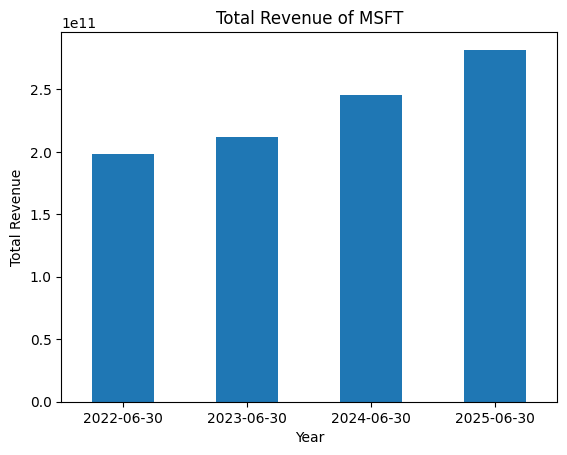

In [18]:
import matplotlib.pyplot as plt
import yfinance as yf

# Set the ticker as MSFT
msft = yf.Ticker("MSFT")

# Get the financials data and sort the columns (dates) in ascending order
financials = msft.financials.sort_index(axis=1)

# Select the 'Total Revenue' row
total_revenue = financials.loc['Total Revenue']

# Plot the total revenue as a bar chart
total_revenue.plot.bar()

# Format the x-axis to show dates without time
plt.xticks(range(len(total_revenue.index)), total_revenue.index.strftime('%Y-%m-%d'), rotation=0)
plt.xlabel('Year')
plt.ylabel('Total Revenue')
plt.title('Total Revenue of MSFT')

# Show the plot
plt.show()


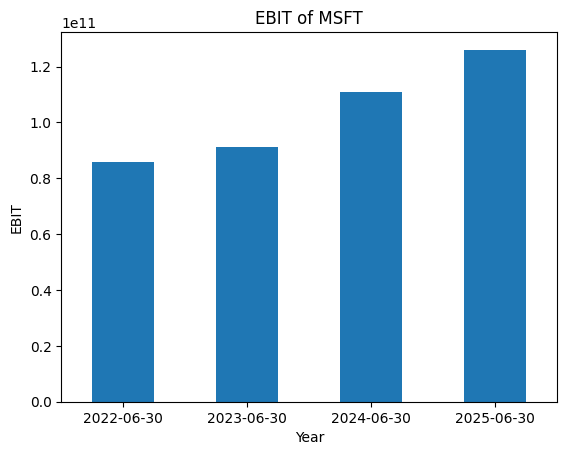

In [19]:
import matplotlib.pyplot as plt
import yfinance as yf

# Set the ticker as MSFT
msft = yf.Ticker("MSFT")

# Get the financials data and sort the columns (dates) in ascending order
financials = msft.financials.sort_index(axis=1)

# Select the 'Total Revenue' row
EBIT = financials.loc['EBIT']

# Plot the total revenue as a bar chart
EBIT.plot.bar()

# Format the x-axis to show dates without time
plt.xticks(range(len(EBIT.index)), EBIT.index.strftime('%Y-%m-%d'), rotation=0)
plt.xlabel('Year')
plt.ylabel('EBIT')
plt.title('EBIT of MSFT')

# Show the plot
plt.show()

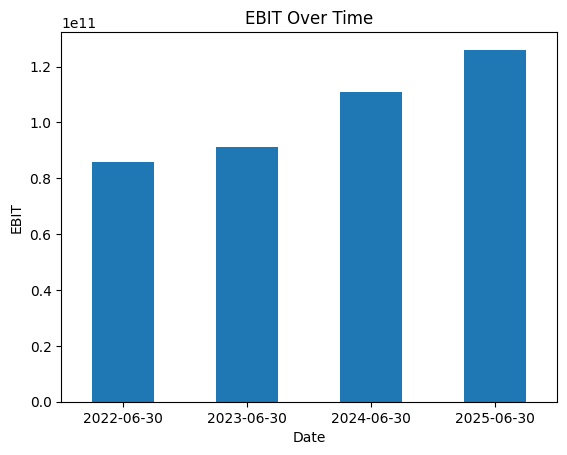

In [20]:
# Sorting the MSFT EBIT data
EBIT_sorted = EBIT.sort_values(ascending=True)

# Plotting the sorted EBIT
EBIT_sorted.plot.bar()
plt.xticks(range(len(EBIT_sorted.index)), EBIT_sorted.index.strftime('%Y-%m-%d'), rotation=0)
plt.xlabel('Date')
plt.ylabel('EBIT')
plt.title('EBIT Over Time')
plt.show()

Index(['Tax Effect Of Unusual Items', 'Tax Rate For Calcs',
       'Normalized EBITDA', 'Total Unusual Items',
       'Total Unusual Items Excluding Goodwill',
       'Net Income From Continuing Operation Net Minority Interest',
       'Reconciled Depreciation', 'Reconciled Cost Of Revenue', 'EBITDA',
       'EBIT', 'Net Interest Income', 'Interest Expense', 'Interest Income',
       'Normalized Income',
       'Net Income From Continuing And Discontinued Operation',
       'Total Expenses', 'Total Operating Income As Reported',
       'Diluted Average Shares', 'Basic Average Shares', 'Diluted EPS',
       'Basic EPS', 'Diluted NI Availto Com Stockholders',
       'Net Income Common Stockholders', 'Net Income',
       'Net Income Including Noncontrolling Interests',
       'Net Income Continuous Operations', 'Tax Provision', 'Pretax Income',
       'Other Income Expense', 'Other Non Operating Income Expenses',
       'Special Income Charges', 'Write Off', 'Gain On Sale Of Security',
  

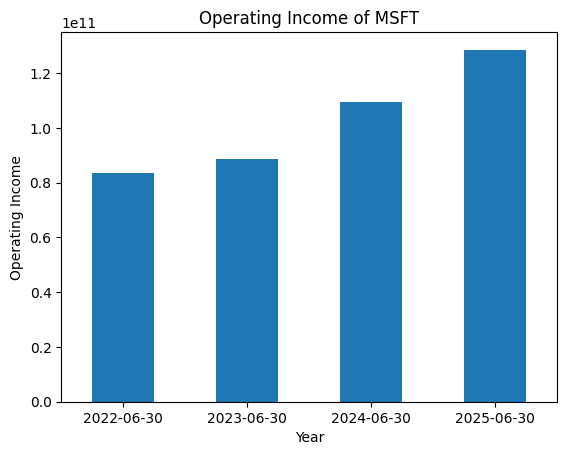

In [21]:
# Checking Operating income or EBIT (Earnings before interest and tax)
import yfinance as yf

# Set the ticker as MSFT
msft = yf.Ticker("MSFT")

# Get the financials data
financials = msft.financials

# Display the available rows in the financials DataFrame
print(financials.index)
import matplotlib.pyplot as plt
import yfinance as yf

# Set the ticker as MSFT
msft = yf.Ticker("MSFT")

# Get the financials data and sort the columns (dates) in ascending order
financials = msft.financials.sort_index(axis=1)

# Check if 'Operating Income' is available
if 'Operating Income' in financials.index:
    # Select the 'Operating Income' row
    operating_income = financials.loc['Operating Income']

    # Plot Operating Income as a bar chart (acting as a proxy for EBIT)
    operating_income.plot.bar()

    # Format the x-axis to show dates without time
    plt.xticks(range(len(operating_income.index)), operating_income.index.strftime('%Y-%m-%d'), rotation=0)
    plt.xlabel('Year')
    plt.ylabel('Operating Income')
    plt.title('Operating Income of MSFT')
    # Show the plot
    plt.show()
else:
    print("Operating Income data is not available.")

In [22]:
# If you already have a version of pyfolio on your system you can remove that using !pip uninstall pyfolio and then run the following code
!pip install pyfolio-reloaded==0.9.5

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 33.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 48.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 78.0 MB/s eta 0:00:00
  Created wheel for peewee: filename=peewee-3.17.3-py3-none-any.whl size=138487 sha256=cf434eac57f1ad44166235e72d1572b2d27e3bf70813e094c6363e8d21c2bb20
  Stored in directory: /root/.cache/pip/wheels/39/c7/dd/909d267742f7fbb941ff081dacd661f622a0b4eb38f667b84b
Successfully built peewee
  Attempting uninstall: peewee
    Found existing installation: peewee 3.18.3
    Uninstalling peewee-3.18.3:
      Successfully uninstalled peewee-3.18.3


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
/usr/local/lib/python3.12/dist-packages/pyfolio/pos.py:25: UserWarning: Module "zipline.assets" not found; multipliers will not be applied to position notionals.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pyfolio/plotting.py:666: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '17.605%' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  perf_stats.loc[stat, column] = str(np.round(value * 100, 3)) + "%"


Start date,2020-11-24
End date,2025-11-21
Total months,59
,Backtest
Annual return,17.605%
Cumulative returns,124.251%
Annual volatility,21.342%
Sharpe ratio,0.87
Calmar ratio,0.60
Stability,0.78
Max drawdown,-29.312%


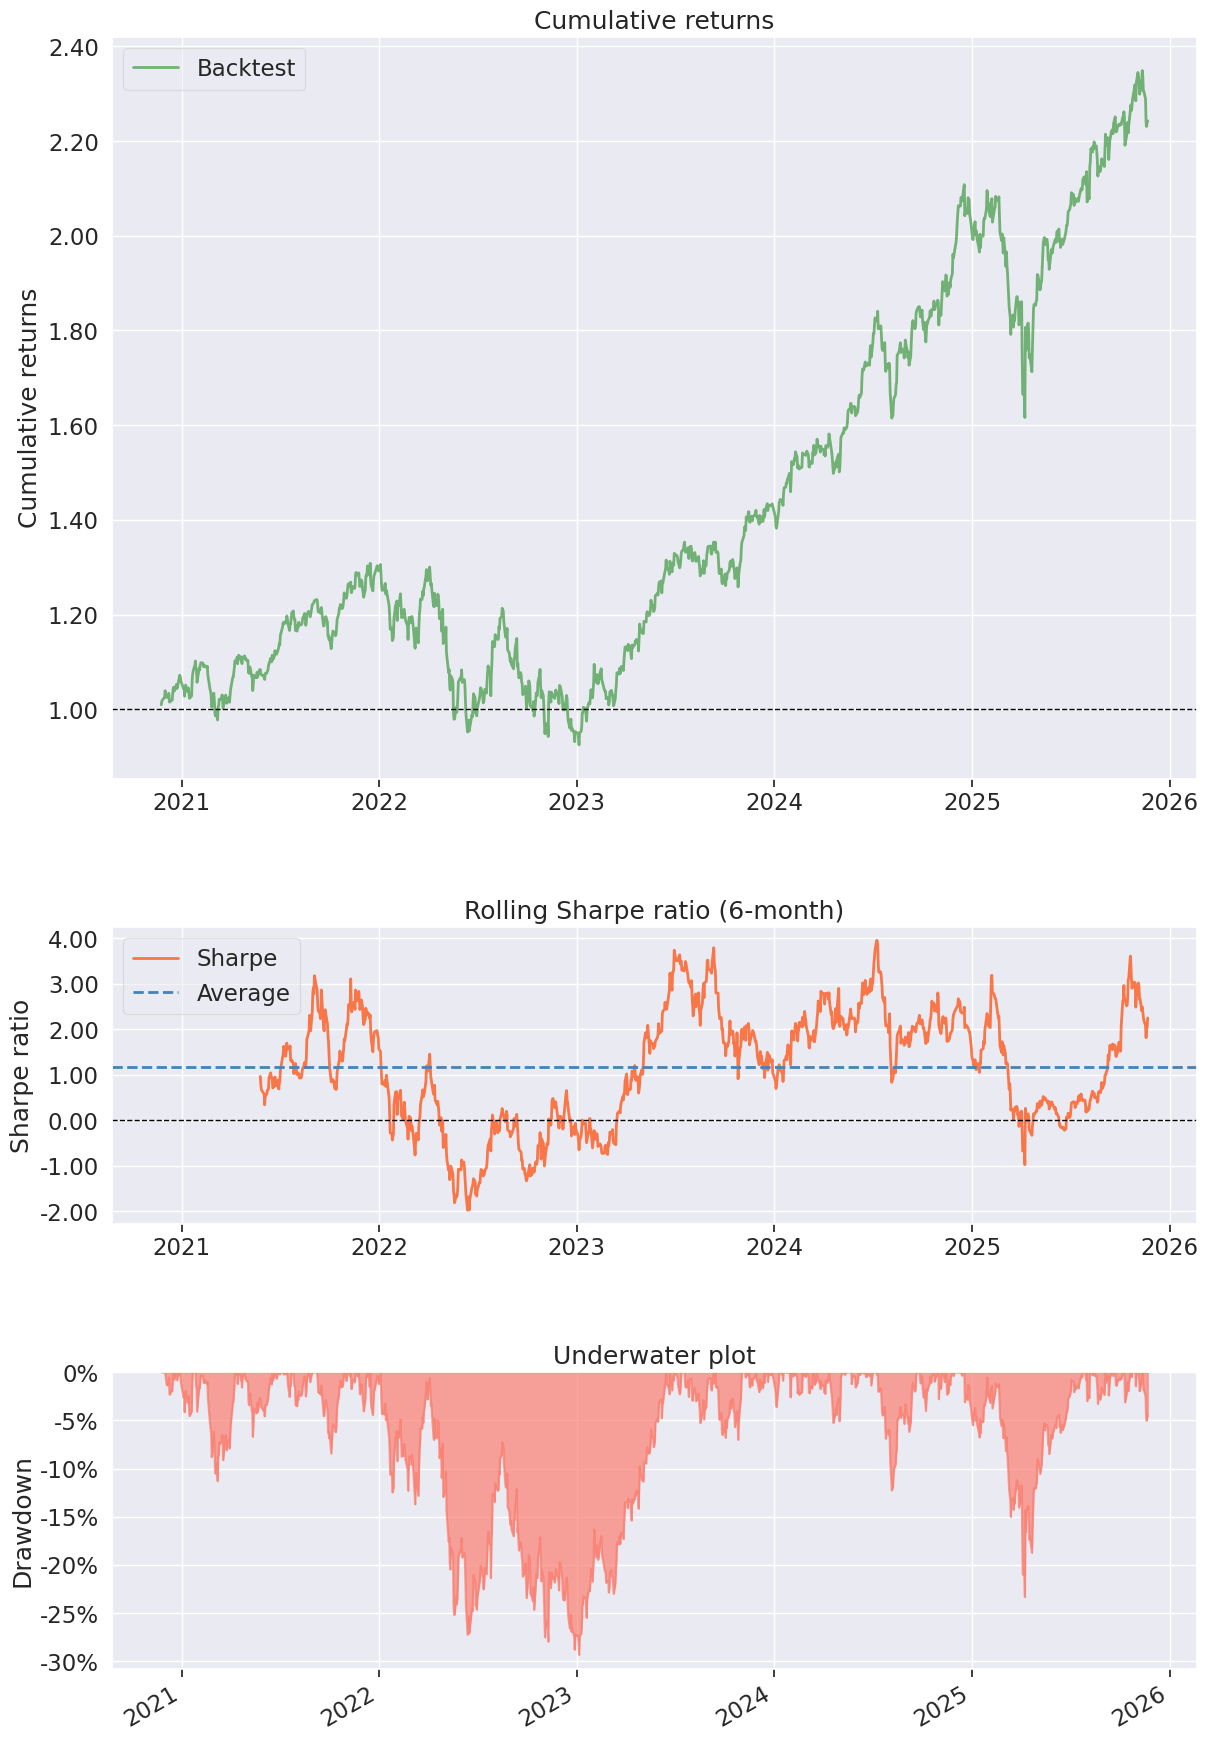

In [1]:
# Define the ticker list
tickers_list = ['AAPL', 'AMZN', 'MSFT', 'WMT']

# Import pandas and create a placeholder for the data
import pandas as pd
data = pd.DataFrame(columns=tickers_list)

# Fetch the data
import yfinance as yf
for ticker in tickers_list:
     data[ticker] = yf.download(ticker, period='5y', auto_adjust=False)['Adj Close']

# Compute the returns of individual stocks and then compute the daily mean returns.
# The mean return is the daily portfolio returns with the above four stocks.
data = data.pct_change().dropna().mean(axis=1)

# Import Pyfolio
import pyfolio as pf

# Get the full tear sheet
pf.create_simple_tear_sheet(data)

/tmp/ipython-input-2984257721.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  stock_data = yf.download('AAPL', start='2020-01-01', end='2024-08-01')
[*********************100%***********************]  1 of 1 completed


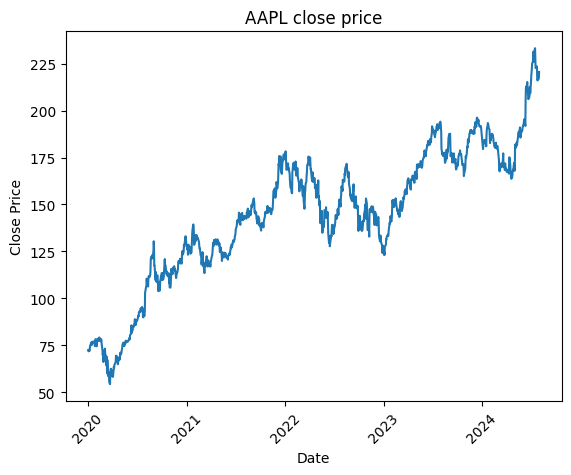

In [2]:
import yfinance as yf
import matplotlib.pyplot as plt

# Download historical stock data for Apple (AAPL)
stock_data = yf.download('AAPL', start='2020-01-01', end='2024-08-01')

# Plotting the closing price over time
plt.plot(stock_data.index, stock_data['Close'])
plt.title('AAPL close price')
plt.xlabel('Date')
plt.ylabel('Close Price')
# Rotate x-axis labels
plt.xticks(rotation=45)
plt.show()


In [4]:
import yfinance as yf
import plotly.graph_objects as go

# Download historical stock data for Apple (AAPL)
stock_data = yf.download('AAPL', start='2020-01-01', end='2025-11-21', group_by='ticker')['AAPL']

# Plotting the candlestick chart with Plotly
fig = go.Figure(data=[go.Candlestick(x=stock_data.index,
                                     open=stock_data['Open'],
                                     high=stock_data['High'],
                                     low=stock_data['Low'],
                                     close=stock_data['Close'])])
fig.update_layout(title='AAPL Candlestick Chart', xaxis_title='Date', yaxis_title='Price')

# Display the figure
fig.show()


/tmp/ipython-input-728088143.py:5: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


/tmp/ipython-input-2347815472.py:5: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


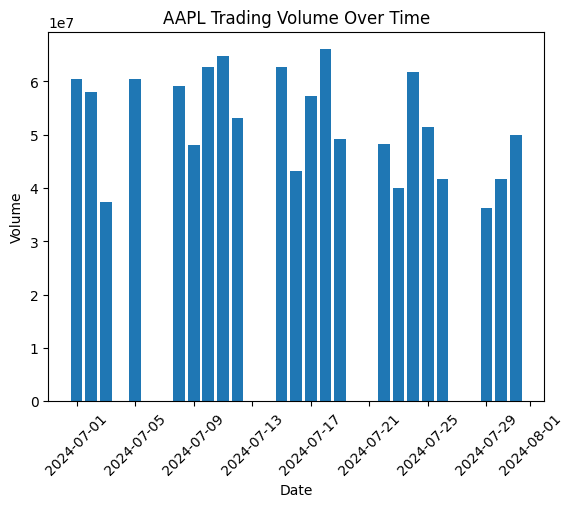

In [5]:
import yfinance as yf
import matplotlib.pyplot as plt

# Download historical stock data for Apple (AAPL)
stock_data = yf.download('AAPL', start='2024-07-01', end='2024-08-01', group_by='ticker')['AAPL']

# Plotting the trading volume over time with a bar chart
plt.bar(stock_data.index, stock_data['Volume'])
plt.title('AAPL Trading Volume Over Time')
plt.xlabel('Date')
plt.ylabel('Volume')
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.show()

/tmp/ipython-input-2996772092.py:5: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


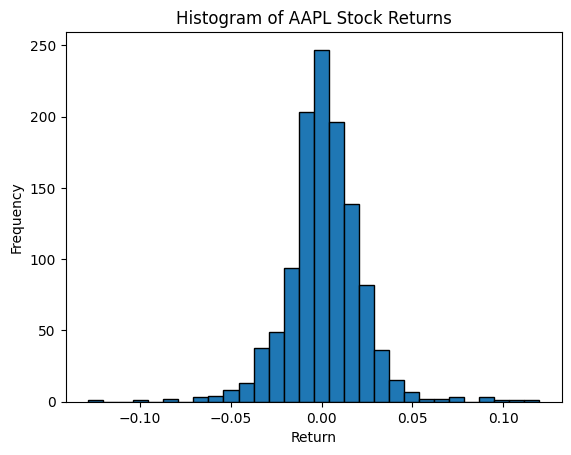

In [6]:
import yfinance as yf
import matplotlib.pyplot as plt

# Download historical stock data for Apple (AAPL)
stock_data = yf.download('AAPL', start='2020-01-01', end='2024-08-01')

# Calculate daily returns
stock_data['Return'] = stock_data['Close'].pct_change()

# Drop NaN values that result from the percentage change calculation
stock_data = stock_data.dropna()

# Plotting the histogram of stock returns
plt.hist(stock_data['Return'], bins=30, edgecolor='black')
plt.title('Histogram of AAPL Stock Returns')
plt.xlabel('Return')
plt.ylabel('Frequency')
plt.show()


/tmp/ipython-input-3296523893.py:5: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


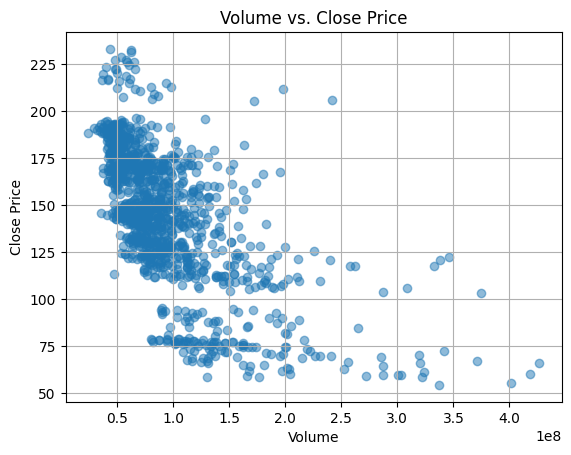

In [7]:
import yfinance as yf
import matplotlib.pyplot as plt

# Download historical stock data for Apple (AAPL)
stock_data = yf.download('AAPL', start='2020-01-01', end='2024-08-01')

# Scatter plot of Volume vs. Close Price
plt.scatter(stock_data['Volume'], stock_data['Close'], alpha=0.5)
plt.title('Volume vs. Close Price')
plt.xlabel('Volume')
plt.ylabel('Close Price')
plt.grid(True)
plt.show()


/tmp/ipython-input-2366658835.py:9: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  5 of 5 completed


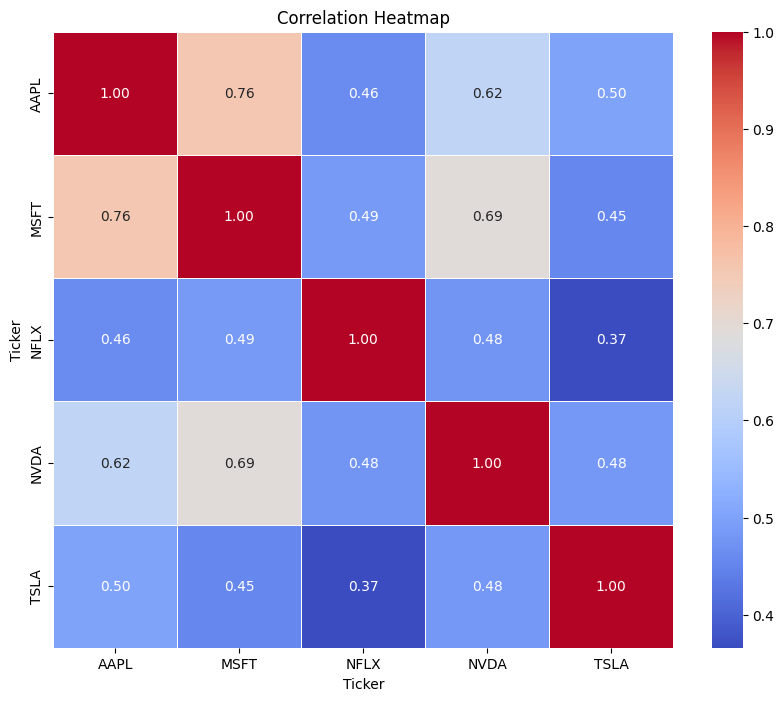

In [8]:
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt

# Set the tickers
tickers = ['AAPL', 'MSFT', 'TSLA', 'NFLX', 'NVDA']

# Download historical stock data for the above tickers
stock_data = yf.download(tickers, start='2020-01-01', end='2024-08-01')['Close']

# Calculate the correlation matrix
correlation_matrix = stock_data.pct_change().dropna().corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.savefig('image.png')
plt.show()

/tmp/ipython-input-2380093683.py:6: FutureWarning:

YF.download() has changed argument auto_adjust default to True

[*********************100%***********************]  1 of 1 completed


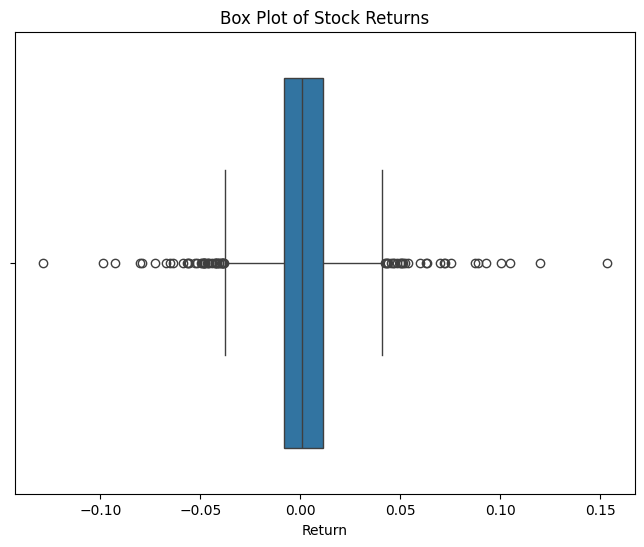

In [10]:
import yfinance as yf
import seaborn as sns
import matplotlib.pyplot as plt

# Download historical stock data for Apple (AAPL)
stock_data = yf.download('AAPL', start='2020-01-01', end='2025-11-21')

# Calculate daily returns
stock_data['Return'] = stock_data['Close'].pct_change()

# Drop NaN values resulting from the percentage change calculation
stock_data = stock_data.dropna()

# Plotting the box plot of stock returns
plt.figure(figsize=(8, 6))
sns.boxplot(x=stock_data['Return'])
plt.title('Box Plot of Stock Returns')
plt.xlabel('Return')
plt.show()
